# Krylov Subspace Solver Benchmark Analysis (Native vs SME vs SME+SEV)

This notebook analyses Krylov subspace solver benchmark results across multiple configurations.  
The goal is to quantify performance behaviour and overheads of encrypted modes (`SME`, `SME+SEV`) relative to `Native`.

## What this notebook does

- Loads run-level benchmark CSV results from multiple output folders.
- Derives per-configuration attributes (matrix size in MiB, symmetry, IPC, time breakdowns).
- Cleans run-level metrics using IQR-based outlier handling.
- Aggregates metrics per configuration using medians.
- Builds a baseline comparison against `Native` and computes percentage overheads for:
	- runtime (`SpMV_Time`, `Mgmt_Time`, `Total_Time`, `Time_per_op`)
	- hardware counters (cycles, instructions, cache misses, dTLB misses, IPC)
- Visualises overhead distributions and breakdowns by key dimensions:
	- VM NUMA policy
	- core count
	- algorithm
	- matrix identity
- Applies ANOVA/effect-size analysis to identify dominant factors.

## Output

The notebook prints intermediate summaries/tables and saves publication-style figures (PDF) under `images/`.


# 0. Setup

Imports, paths, and shared helpers used throughout the notebook.

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from matplotlib.patches import Patch
from statsmodels.formula.api import ols

sys.path.append("..")
import common_style as cs

cs.apply_style()
MODE_PALETTE = cs.MODE_PALETTE
MODE_PALETTE_2 = cs.MODE_PALETTE_2

os.makedirs("images", exist_ok=True)


In [2]:
# ── File paths ───────────────────────────────────────────────────────────────
matrix_path  = "../../matrices/binary_spmc"
results_path = "../../outputs/krylov"

FOLDERS = {
    "Native":             results_path + "/native/",
    "SME":                results_path + "/sme/",
    "SME+SEV":            results_path + "/sev/",
    "Native_interleave":  results_path + "/native_interleave/",
    "SME_interleave":     results_path + "/sme_interleave/",
    "SME+SEV_interleave": results_path + "/sev_interleave/",
}


In [3]:
def get_mb(matrix_name, symmetric):
    """Return the file size in MiB for the given matrix.

    Looks under `symmetric/` or `unsymmetric/` depending on the flag.
    """
    sub    = "symmetric" if symmetric else "unsymmetric"
    f_path = os.path.join(matrix_path, sub, matrix_name)
    try:
        return round(os.path.getsize(f_path) / (1024 ** 2))
    except FileNotFoundError:
        return None


def iqr_filter(df, cols, k=1.5):
    """Keep only rows within k*IQR of the median for each column in `cols`."""
    mask = pd.Series(True, index=df.index)
    for c in cols:
        q1, q3 = df[c].quantile([0.25, 0.75])
        iqr    = q3 - q1
        mask  &= df[c].between(q1 - k * iqr, q3 + k * iqr)
    return df[mask]


def full_anova(df, target):
    """Run a Type-III ANOVA for `target` on the standard Krylov predictor set.

    Returns a DataFrame sorted by effect size (eta²) descending.
    Residual row is dropped before returning.
    """
    d       = df.dropna(subset=[target, "Algo", "Cores", "Matrix", "Process_NUMA", "VM_NUMA"]).copy()
    formula = f"{target} ~ C(Algo) + C(Matrix) + Cores + C(Process_NUMA) + C(VM_NUMA)"
    model   = ols(formula, data=d).fit()
    table   = sm.stats.anova_lm(model, typ=3)
    table["eta_sq"] = table["sum_sq"] / table["sum_sq"].sum()
    return (
        table.drop(index="Residual", errors="ignore")
        .sort_values("eta_sq", ascending=False)
    )


# 1. Data Preparation

Load run-level CSVs, apply per-metric IQR outlier removal, then aggregate to 
one median row per configuration.

In [ ]:
results_list = []

for label, path in FOLDERS.items():
    f_path = os.path.join(path, "results.csv")
    if os.path.exists(f_path):
        df_run            = pd.read_csv(f_path)
        df_run["Mode"]    = label.split("_interleave")[0]
        df_run["VM_NUMA"] = "interleave" if "interleave" in label else "strict"
        df_run['Process_NUMA_Policy'] = df_run['Process_NUMA_Policy'].replace({'membind': 'strict'})
        results_list.append(df_run)
        print(f"Loaded {len(df_run):>5} rows  ← {label}")

df_raw = pd.concat(results_list, ignore_index=True)
df_raw.rename(columns={"Process_NUMA_Policy": "Process_NUMA"}, inplace=True)
print(f"\nTotal rows: {len(df_raw)}")


Loaded  2400 rows  ← Native
Loaded  2400 rows  ← SME
Loaded  2400 rows  ← SME+SEV
Loaded  2400 rows  ← Native_interleave
Loaded  2400 rows  ← SME_interleave
Loaded  2400 rows  ← SME+SEV_interleave

Total rows: 14400


In [5]:
config_cols_raw = ["Mode", "Matrix", "Cores", "Process_NUMA", "VM_NUMA",
                   "Algo", "Arg1", "Arg2", "Arg3", "N_Ops"]
metric_cols_raw = ["SpMV_Time", "Mgmt_Time", "Perf_Cycles", "Perf_Instructions",
                   "Perf_CacheMisses", "Perf_dTLBMisses"]

config_drop_counts = []

def _iqr_mark_outliers(group):
    """Replace per-metric outliers (IQR method) with NaN within a config group."""
    group       = group.copy()
    group_drops = 0
    for col in metric_cols_raw:
        if col not in group.columns:
            continue
        valid_rows    = group[[col]].dropna()
        if valid_rows.empty:
            continue
        filtered_rows = iqr_filter(valid_rows, [col])
        outlier_idx   = valid_rows.index.difference(filtered_rows.index)
        group_drops  += len(outlier_idx)
        group.loc[outlier_idx, col] = np.nan
    config_drop_counts.append(group_drops)
    return group

df_clean = (
    df_raw.groupby(config_cols_raw)
    .apply(_iqr_mark_outliers, include_groups=False)
    .reset_index()
)

total_removed = sum(config_drop_counts)
total_pts     = len(df_raw) * len(metric_cols_raw)
print(f"Total metric data points:    {total_pts}")
print(f"Outlier data points removed: {total_removed} ({total_removed / total_pts * 100:.2f}%)")


Total metric data points:    86400
Outlier data points removed: 2608 (3.02%)


In [6]:
def compute_cv(df, config_cols, metrics):
    """Return mean coefficient of variation per metric across all configs."""
    stats = df.groupby(config_cols)[metrics].agg(["mean", "std"])
    cv    = stats.xs("std", level=1, axis=1) / stats.xs("mean", level=1, axis=1)
    return cv.mean()


cv_raw   = compute_cv(df_raw,   config_cols_raw, metric_cols_raw)
cv_clean = compute_cv(df_clean, config_cols_raw, metric_cols_raw)

print("Mean CV — raw data:")
print(cv_raw.round(3).to_string())
print("\nMean CV — IQR-cleaned data:")
print(cv_clean.round(3).to_string())


Mean CV — raw data:
SpMV_Time            0.003
Mgmt_Time            0.004
Perf_Cycles          0.002
Perf_Instructions    0.000
Perf_CacheMisses     0.010
Perf_dTLBMisses      0.067

Mean CV — IQR-cleaned data:
SpMV_Time            0.003
Mgmt_Time            0.003
Perf_Cycles          0.002
Perf_Instructions    0.000
Perf_CacheMisses     0.009
Perf_dTLBMisses      0.060


In [7]:
# Aggregate to one median row per configuration, then derive extra columns
df = df_clean.groupby(config_cols_raw)[metric_cols_raw].median().reset_index()

# 'bicgstab' contains 'cg' but is *not* symmetric — explicit check required
df["Symmetric"]   = df["Algo"].apply(lambda x: ("cg" in x or "lanczos" in x) and "bicg" not in x)
df["MB"]          = df.apply(lambda row: get_mb(row["Matrix"], row["Symmetric"]), axis=1).astype("Int64")
df["Matrix"]      = df["Matrix"].str.replace(".bin", "", regex=False)
df["Perf_IPC"]    = df["Perf_Instructions"] / df["Perf_Cycles"]
df["Total_Time"]  = df["SpMV_Time"] + df["Mgmt_Time"]
df["Time_per_op"] = df["Total_Time"] / df["N_Ops"]
df["SpMV_Ratio"]  = df["SpMV_Time"] / df["Total_Time"]

metric_cols = metric_cols_raw + ["Perf_IPC", "Time_per_op"]

df.head()


,Mode,Matrix,Cores,Process_NUMA,VM_NUMA,Algo,Arg1,Arg2,Arg3,N_Ops,...,Perf_Cycles,Perf_Instructions,Perf_CacheMisses,Perf_dTLBMisses,Symmetric,MB,Perf_IPC,Total_Time,Time_per_op,SpMV_Ratio
0,Native,Bump2911,1,interleave,interleave,cg,159,0,0,159,...,3.561613e+10,1.536218e+11,58302643.0,533281.0,True,<NA>,4.313265,9.801176,0.061643,0.864033
1,Native,Bump2911,1,interleave,interleave,lanczos,11,2,10,106,...,3.147399e+10,1.198801e+11,37869017.0,257503.0,True,<NA>,3.808863,8.781362,0.082843,0.647692
2,Native,Bump2911,1,interleave,strict,cg,159,0,0,159,...,3.701111e+10,1.536218e+11,58115339.0,516729.0,True,<NA>,4.150694,10.187805,0.064074,0.863784
3,Native,Bump2911,1,interleave,strict,lanczos,11,2,10,106,...,3.208136e+10,1.198801e+11,37515727.0,247792.0,True,<NA>,3.736755,8.941120,0.084350,0.657623
4,Native,Bump2911,1,membind,interleave,cg,159,0,0,159,...,3.557956e+10,1.536218e+11,58030389.0,504352.5,True,<NA>,4.317698,9.790518,0.061576,0.863985


# 2. Absolute Baselines

Examine raw performance (not yet relative to Native) to understand absolute 
behaviour per mode before computing overheads.

## 2.1 VM NUMA policy — time per operation

Mean time per operation (s):
Mode     VM_NUMA   
Native   interleave    0.026670
         strict        0.028410
SME      interleave    0.027366
         strict        0.029777
SME+SEV  interleave    0.027418
         strict        0.030023


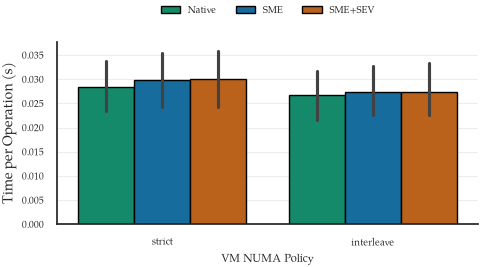

In [8]:
fig, ax = plt.subplots(figsize=(5, 3))
sns.barplot(
    data=df, x="VM_NUMA", y="Time_per_op", hue="Mode",
    order=["strict", "interleave"],
    palette=MODE_PALETTE, edgecolor="black", ax=ax,
)
ax.set_xlabel("VM NUMA Policy")
ax.set_ylabel("Time per Operation (s)", fontsize=10)
ax.legend(title=None, loc="upper center", bbox_to_anchor=(0.5, 1.25), ncol=3)
fig.tight_layout()
fig.savefig("images/krylov_vm_numa.pdf", bbox_inches="tight")

print("Mean time per operation (s):")
print(df.groupby(["Mode", "VM_NUMA"])["Time_per_op"].mean().round(6).to_string())


## 2.2 VM NUMA boost heatmap

GFLOPS-equivalent reduction (%) when switching from `strict` to `interleave` VM NUMA, 
broken down by Matrix × Cores per mode. Matrices are grouped by symmetry class.

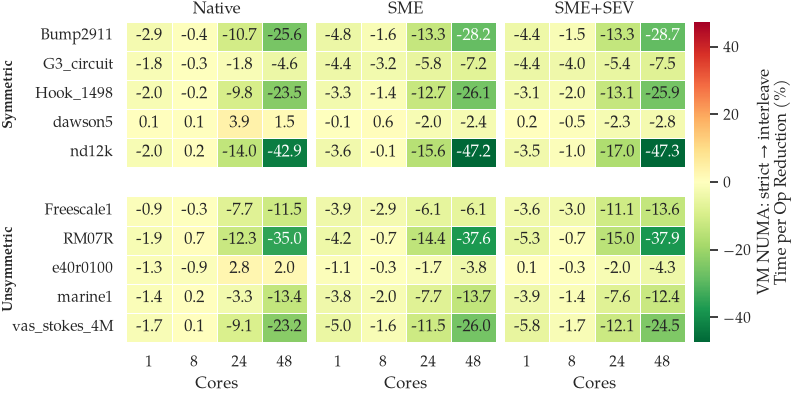

In [9]:
# VM_NUMA boost: interleave vs strict
sns.set_theme(style="white", font="TeX Gyre Pagella")
heat_df = (
	df.pivot_table(
		index=["Mode", "Algo", "Matrix", "Cores", "Process_NUMA"],
		columns="VM_NUMA",
		values="Time_per_op",
		aggfunc="mean"
	)
	.dropna(subset=["interleave", "strict"])
	.reset_index()
)

heat_df["Boost_pct"] = (heat_df["interleave"] - heat_df["strict"]) / heat_df["strict"] * 100

mode_cell = (
	heat_df.groupby(["Matrix", "Cores", "Mode"], as_index=False)["Boost_pct"]
	.mean()
)

mode_order = ["Native", "SME", "SME+SEV"]
modes = [m for m in mode_order if m in mode_cell["Mode"].unique()]

vabs = mode_cell["Boost_pct"].abs().max()
fig, axes = plt.subplots(1, len(modes), figsize=(8, 4), constrained_layout=True, sharey=True)
fig.patch.set_facecolor("white")

if len(modes) == 1:
	axes = [axes]

for i, mode in enumerate(modes):
	axes[i].set_facecolor("white")
	axes[i].grid(False)

	p_mode = (
		mode_cell[mode_cell["Mode"] == mode]
		.pivot(index="Matrix", columns="Cores", values="Boost_pct")
	)
	p_mode = p_mode.reindex(sorted(p_mode.columns), axis=1)

	mb_map = df[["Matrix", "MB"]].drop_duplicates().set_index("Matrix")["MB"].astype(float).fillna(0.0)
	sym_map = df[["Matrix", "Symmetric"]].drop_duplicates().set_index("Matrix")["Symmetric"]

	available_rows = list(p_mode.index)
	sym_rows = [m for m in available_rows if bool(sym_map.get(m, False))]
	unsym_rows = [m for m in available_rows if not bool(sym_map.get(m, False))]

	sym_sorted = sorted(sym_rows, key=lambda m: int(mb_map.get(m, 0)))
	unsym_sorted = sorted(unsym_rows, key=lambda m: int(mb_map.get(m, 0)))

	combined_index = sym_sorted + [""] + unsym_sorted
	p_combined = p_mode.reindex(combined_index)
	mask = p_combined.isna()

	sns.heatmap(
		p_combined,
		ax=axes[i],
		cmap="RdYlGn_r",
		center=0,
		vmin=-vabs,
		vmax=vabs,
		annot=True,
		fmt=".1f",
		linewidths=0.4,
		linecolor="white",
		mask=mask,
		cbar=(i == len(modes) - 1),
		cbar_kws={"label": "VM NUMA: strict → interleave\nTime per Op Reduction (%)"} if i == len(modes) - 1 else None
	)

	if i == 0:
		sym_count = len(sym_sorted)
		unsym_count = len(unsym_sorted)

		if sym_count > 0:
			sym_y = sym_count / 2.0
			axes[i].text(-2.6, sym_y, "Symmetric", va="center", ha="center",
						 rotation=90, fontweight="bold", fontsize=10,clip_on=False)
		if unsym_count > 0:
			unsym_y = sym_count + 1 + (unsym_count / 2.0)
			axes[i].text(-2.6, unsym_y, "Unsymmetric", va="center", ha="center",
						 rotation=90, fontweight="bold", fontsize=10, clip_on=False)

	axes[i].set_yticks(np.arange(len(p_combined.index)) + 0.5)
	axes[i].set_yticklabels(p_combined.index, rotation=0)

	axes[i].set_title(mode)
	axes[i].set_xlabel("Cores")
	if i == 0:
		axes[i].set_ylabel("")
	else:
		axes[i].set_ylabel("")
		axes[i].tick_params(axis="y", left=False, labelleft=False)

plt.savefig("images/krylov_vm_numa_heat.pdf", bbox_inches="tight")


## 2.3 SpMV vs management time ratio

Fraction of total execution time spent in SpMV (compute) vs solver management overhead, 
split by algorithm family and core count.

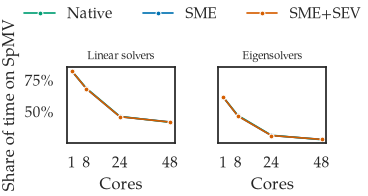


Linear solvers SpMV Ratio (% of total time):
Mode   Native    SME  SME+SEV
Cores                        
1      82.37% 82.33%   82.37%
8      68.60% 68.23%   68.22%
24     46.29% 46.05%   46.04%
48     41.59% 41.89%   41.78%

Eigensolvers SpMV Ratio (% of total time):
Mode   Native    SME  SME+SEV
Cores                        
1      61.59% 61.58%   61.60%
8      47.12% 46.66%   46.62%
24     31.35% 31.16%   31.12%
48     27.86% 28.05%   28.04%


In [10]:
# 1. Prep Data
target_order = [m for m in cs.MODE_ORDER if m in df['Mode'].unique()]
cores = sorted(df['Cores'].unique())

algo_groups = [
    {'name': 'Linear solvers', 'algos': ['cg', 'bicgstab']},
    {'name': 'Eigensolvers', 'algos': ['lanczos', 'arnoldi']},
]

fig, axes = plt.subplots(1, 2, figsize=(cs.COLW, 1.2), sharey=True)

for idx, group in enumerate(algo_groups):
    ax = axes[idx]
    filtered_df = df[df['Algo'].isin(group['algos'])]
    summary = filtered_df.groupby(['Mode', 'Cores'])['SpMV_Ratio'].mean().reset_index()

    sns.lineplot(
        data=summary, x='Cores', y='SpMV_Ratio', hue='Mode',
        hue_order=target_order, palette=cs.MODE_PALETTE, ax=ax,
        marker='o', markersize=3.5, linewidth=1.2, errorbar=None,
    )
    ax.set_title(group['name'], fontsize=8)
    ax.set_xlabel('Cores')
    ax.set_xticks(cores)
    ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
    if idx == 0:
        ax.set_ylabel('Share of time on SpMV')
    cs.remove_legend(ax)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=len(target_order), loc='lower center',
           bbox_to_anchor=(0.5, 1.0), frameon=False)
fig.subplots_adjust(top=0.74, wspace=0.4)

fig.savefig('images/krylov_execution_time_ratio.pdf')
plt.show()

for group in algo_groups:
    print(f'\n{group["name"]} SpMV Ratio (% of total time):')
    filtered_df = df[df['Algo'].isin(group['algos'])]
    summary = filtered_df.groupby(['Mode', 'Cores'])['SpMV_Ratio'].mean().round(4).reset_index()
    summary_pivot = summary.pivot(index='Cores', columns='Mode', values='SpMV_Ratio')
    print(summary_pivot.to_string(float_format='{:.2%}'.format))


### SpMV ratio mode-pair differences

Verify that the SpMV/management split is consistent across modes.

In [11]:
df_diff = df.pivot_table(index=['Algo','Matrix', 'Cores', 'VM_NUMA', 'Process_NUMA'], columns='Mode', values='SpMV_Ratio')
mode_pairs = [('Native', 'SME'), ('Native', 'SME+SEV'), ('SME', 'SME+SEV')]

all_vals = []
for m1, m2 in mode_pairs:
	if m1 in df_diff.columns and m2 in df_diff.columns:
		diff_pp = (df_diff[m1] - df_diff[m2]).abs() * 100
		all_vals.append(diff_pp.values)

all_concat = np.concatenate(all_vals)
overall_avg = np.nanmean(all_concat)
overall_max = np.nanmax(all_concat)
print(f"Overall average absolute SpMV Ratio difference across mode pairs: {overall_avg:.4f} percentage points")
print(f"Overall maximum absolute SpMV Ratio difference across mode pairs: {overall_max:.4f} percentage points")

Overall average absolute SpMV Ratio difference across mode pairs: 0.3477 percentage points
Overall maximum absolute SpMV Ratio difference across mode pairs: 2.5286 percentage points


# 3. Overhead Computation

For each non-Native configuration, compute absolute and percentage overhead 
relative to the matched Native run on the same hardware configuration.

In [12]:
merge_cols = [c for c in config_cols_raw if c != "Mode"]

df_native = df[df["Mode"] == "Native"].copy()
df_other  = df[df["Mode"] != "Native"].copy()

cols_to_keep = merge_cols + metric_cols
overhead_df  = df_other.merge(df_native[cols_to_keep], on=merge_cols, suffixes=("", "_native"))

# Sign convention: positive overhead = worse performance.
#   - time-like metrics (higher = worse):   100 * (m / native - 1)
#   - throughput metrics (higher = better): 100 * (1 - m / native)
throughput_metrics = {"Perf_IPC"}

for m in metric_cols:
    native_col = f"{m}_native"
    if m in throughput_metrics:
        overhead_df[f"{m}_abs"] = overhead_df[native_col] - overhead_df[m]
        overhead_df[f"{m}_pct"] = np.where(
            overhead_df[native_col] != 0,
            (1 - overhead_df[m] / overhead_df[native_col]) * 100,
            np.nan,
        )
    else:
        overhead_df[f"{m}_abs"] = overhead_df[m] - overhead_df[native_col]
        overhead_df[f"{m}_pct"] = np.where(
            overhead_df[native_col] != 0,
            (overhead_df[m] / overhead_df[native_col] - 1) * 100,
            np.nan,
        )
    overhead_df.drop(columns=[native_col, m], inplace=True)


# 4. Time Overhead Overview

Distribution and breakdown of `Time_per_op` overhead (%) relative to Native.

In [13]:
print(overhead_df.groupby("Mode")["Time_per_op_pct"].aggregate(["mean", "median"]).round(2))
print(f"\n90th percentile (all modes): {overhead_df['Time_per_op_pct'].quantile(0.9):.2f}%")


         mean  median
Mode                 
SME      3.16    2.70
SME+SEV  3.59    3.05

90th percentile (all modes): 6.99%


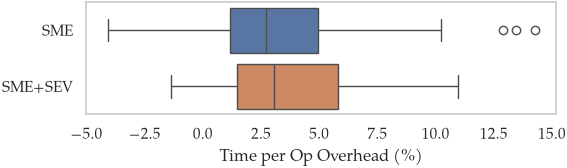

In [14]:
sns.set_theme(style="whitegrid", font="TeX Gyre Pagella")
fig, ax = plt.subplots(figsize=(6, 2))
sns.boxplot(data=overhead_df, x="Time_per_op_pct", y="Mode", hue="Mode", ax=ax)
ax.set_xlabel("Time per Op Overhead (%)")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig("images/Time_per_Op_Overhead_Distribution.pdf", bbox_inches="tight")
plt.show()


## 4.1 Overhead by system dimension

Mean overhead split by VM NUMA policy and core count.

→ VM NUMA:
Mode        SME  SME+SEV
VM_NUMA                 
strict      4.3      5.0
interleave  2.0      2.1
------------------------------------------------------------
→ Cores:
Mode   SME  SME+SEV
Cores              
1      3.1      3.8
8      1.8      2.0
24     4.0      4.2
48     3.6      4.3
------------------------------------------------------------


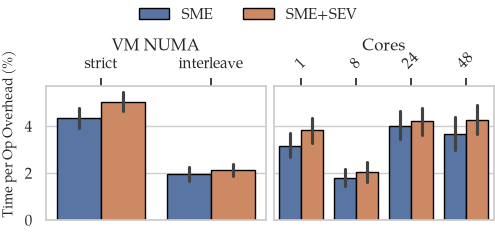

In [15]:
def plot_metric_by_dimensions(metric, metric_legend_name, top):
    """Bar plots of `metric` overhead broken down by VM_NUMA and Cores."""
    all_dims      = ["VM_NUMA", "Cores"]
    vm_numa_order = ["strict", "interleave"]

    fig, axes = plt.subplots(1, len(all_dims), figsize=(5, 2),
                              constrained_layout=True, sharey=True)
    fig.supylabel(f"{metric_legend_name} Overhead (%)", fontsize=10)

    for ax, dim in zip(axes, all_dims):
        sns.barplot(
            data=overhead_df, x=dim, y=metric, hue="Mode",
            order=vm_numa_order if dim == "VM_NUMA" else None,
            errorbar=("ci", 95), edgecolor="black", ax=ax,
        )
        ax.set_title(dim.replace("_", " "), y=1.2)
        ax.set_ylabel("")
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=0 if dim == "VM_NUMA" else 45)
        ax.tick_params(axis="y")
        pos = "top" if top else "bottom"
        ax.xaxis.set_ticks_position(pos)
        ax.xaxis.set_label_position(pos)
        cs.remove_legend(ax)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=2,
               bbox_to_anchor=(0.5, 1.2))
    fig.savefig("images/krylov_overhead_by_dim.pdf", bbox_inches="tight")

    for dim in all_dims:
        print(f"→ {dim.replace('_', ' ')}:")
        summary = (
            overhead_df.groupby([dim, "Mode"])[metric]
            .mean().round(2).reset_index()
            .pivot(index=dim, columns="Mode", values=metric)
        )
        if dim == "VM_NUMA":
            summary = summary.reindex(vm_numa_order)
        print(summary.to_string(float_format="{:.1f}".format))
        print("-" * 60)


plot_metric_by_dimensions("Time_per_op_pct", "Time per Op", top=True)


## 4.2 Overhead by algorithm and matrix

Per-matrix overhead broken down by algorithm, with hatching to distinguish 
algorithms within each symmetry class.

/tmp/ipykernel_62424/3442876317.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")



Symmetric displayed values (Time_per_op_pct):
Group       cg + SME  cg + SME+SEV  lanczos + SME  lanczos + SME+SEV
Matrix                                                              
dawson5         1.36          1.40           1.25               1.97
G3_circuit      4.55          5.62           4.21               4.66
nd12k           2.52          2.80           2.49               2.72
Hook_1498       2.86          3.21           3.31               4.13


/tmp/ipykernel_62424/3442876317.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")



Unsymmetric displayed values (Time_per_op_pct):
Group          bicgstab + SME  bicgstab + SME+SEV  arnoldi + SME  arnoldi + SME+SEV
Matrix                                                                             
e40r0100                 2.13                2.36           1.90               2.32
marine1                  3.03                3.44           3.97               4.39
Freescale1               5.10                5.47           3.95               4.23
RM07R                    3.28                3.57           3.14               3.50
vas_stokes_4M            3.81                5.17           4.21               4.65


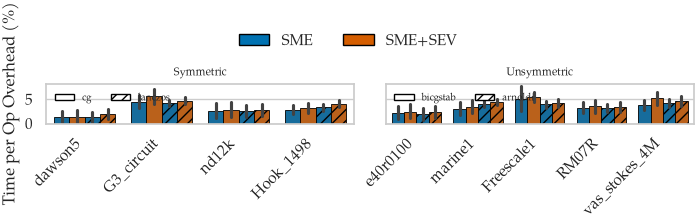

In [16]:
sym_algo_order = ["cg", "lanczos"]
unsym_algo_order = ["bicgstab", "arnoldi"]
algo_patterns = {"cg": "", "lanczos": "///", "bicgstab": "", "arnoldi": "///"}
matrix_order = [
'dawson5', 'G3_circuit', 'nd12k', 'Hook_1498',
'Bump_2911', 'e40r0100', 'marine1', 'Freescale1',
'RM07R', 'vas_stokes_4M'
]

modes_palette = MODE_PALETTE_2

fig, axes = plt.subplots(1, 2, figsize=(cs.TEXTW, 1.6), constrained_layout=True, sharey=True)

for idx, (is_symmetric, title) in enumerate([(True, "Symmetric"), (False, "Unsymmetric")]):
    ax = axes[idx]
    sub = overhead_df[overhead_df["Symmetric"] == is_symmetric].copy()

    sub["Group"] = sub["Algo"] + " + " + sub["Mode"]

    current_algos = sym_algo_order if is_symmetric else unsym_algo_order
    hue_order = [f"{algo} + {mode}" for algo in current_algos for mode in cs.MODE_ORDER_2]

    sns.barplot(
        data=sub,
        x="Matrix",
        y="Time_per_op_pct",
        hue="Group",
        hue_order=hue_order,
        order=[m for m in matrix_order if m in sub["Matrix"].unique()],
        palette=[modes_palette[s.split(" + ")[1]] for s in hue_order],
        errorbar=("ci", 95),
        edgecolor="black",
        linewidth=0.6,
        ax=ax
    )

    for container, group_label in zip(ax.containers, hue_order):
        algo_name = group_label.split(" + ")[0].lower()
        pattern = algo_patterns.get(algo_name, "")
        for bar in container:
            bar.set_hatch(pattern)
            bar.set_edgecolor("black")

    ax.set_title(title, fontsize=8)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_xlabel("")
    ax.set_ylabel("")
    cs.remove_legend(ax)

    if idx == 0:
        ax.set_ylabel("Time per Op Overhead (%)")

    algo_handles = [
        Patch(facecolor="white", edgecolor="black", hatch=algo_patterns.get(a.lower(), ""), label=a)
        for a in current_algos
    ]
    ax.legend(handles=algo_handles, title=None, loc="upper left", ncol=2, fontsize=7, frameon=False)

    print(f"\n{title} displayed values (Time_per_op_pct):")
    displayed_values = (
        sub.groupby(["Matrix", "Group"])["Time_per_op_pct"]
        .mean()
        .unstack("Group")
        .reindex(index=[m for m in matrix_order if m in sub["Matrix"].unique()], columns=hue_order)
    )
    print(displayed_values.round(2).to_string())

mode_handles = [Patch(facecolor=modes_palette[m], edgecolor="black", label=m) for m in cs.MODE_ORDER_2]
fig.legend(handles=mode_handles, title=None, loc="lower center",
           bbox_to_anchor=(0.5, 1.0), ncol=2, frameon=False)

fig.savefig("images/krylov_overhead_by_algo_matrix.pdf")
plt.show()


# 5. Hardware Counter Analysis

Examine instruction count, cycle count, cache misses, and dTLB misses 
relative to Native.

## 5.1 Instructions & Cycles

In [17]:
print(
    overhead_df.groupby("Mode")[["Perf_Instructions_pct", "Perf_Cycles_pct"]]
    .aggregate(["mean", "std"])
    .round(1)
    .to_string()
)

        Perf_Instructions_pct      Perf_Cycles_pct     
                         mean  std            mean  std
Mode                                                   
SME                       0.1  0.4             2.2  2.1
SME+SEV                   0.1  0.4             2.3  2.3


## 5.2 Cache misses & dTLB misses

In [18]:
for metric, label in [
    ("Perf_CacheMisses_pct", "Cache Misses"),
    ("Perf_dTLBMisses_pct",  "dTLB Misses"),
]:
    print(f"{label} — median overhead (%):")
    print(overhead_df.groupby("Mode")[metric].median().round(2).to_string())
    iqr_vals = overhead_df.groupby("Mode")[metric].agg(
        lambda x: x.quantile(0.75) - x.quantile(0.25)
    )
    print(f"{label} — IQR (%)")
    print(iqr_vals.round(2).to_string())
    print()


Cache Misses — median overhead (%):
Mode
SME        0.17
SME+SEV    0.05
Cache Misses — IQR (%)
Mode
SME        7.49
SME+SEV    7.59

dTLB Misses — median overhead (%):
Mode
SME        1.46
SME+SEV    6.18
dTLB Misses — IQR (%)
Mode
SME        12.41
SME+SEV    20.90



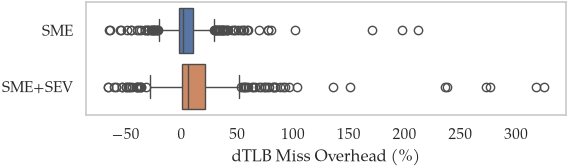

         Perf_dTLBMisses_pct
Mode                        
SME                     1.46
SME+SEV                 6.18


In [19]:
fig, ax = plt.subplots(figsize=(6, 2))
sns.boxplot(data=overhead_df, x="Perf_dTLBMisses_pct", y="Mode", hue="Mode", ax=ax)
ax.set_xlabel("dTLB Miss Overhead (%)")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig("images/CacheMiss_Overhead_Distribution.pdf", bbox_inches="tight")
plt.show()
print(overhead_df.groupby("Mode")[["Perf_dTLBMisses_pct"]].median().round(2).to_string())


## 5.3 dTLB miss vs time overhead correlation (SME vs SME+SEV)

Isolate the incremental SEV contribution by differencing SME+SEV and SME metrics.

> **Sign convention:**  
> * Time diff > 0 → SEV incurs *more* overhead than SME alone  
> * dTLB diff > 0 → SEV incurs *more* dTLB misses than SME alone


Pearson : 0.0869
Spearman: 0.0989


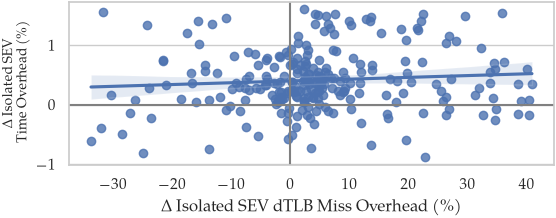

In [20]:
pivot = overhead_df.pivot_table(
    index=["Matrix", "Cores", "VM_NUMA", "Process_NUMA", "Algo"],
    columns="Mode",
    values=["Time_per_op_pct", "Perf_dTLBMisses_pct"],
)
pivot.columns = ["_".join(col) for col in pivot.columns]

pivot["Time_diff"] = pivot["Time_per_op_pct_SME+SEV"] - pivot["Time_per_op_pct_SME"]
pivot["dTLB_diff"] = pivot["Perf_dTLBMisses_pct_SME+SEV"] - pivot["Perf_dTLBMisses_pct_SME"]

corr_df  = pivot[["Time_diff", "dTLB_diff"]].dropna()
corr_iqr = iqr_filter(corr_df, ["Time_diff", "dTLB_diff"])

print("Pearson :", corr_iqr["Time_diff"].corr(corr_iqr["dTLB_diff"], method="pearson").round(4))
print("Spearman:", corr_iqr["Time_diff"].corr(corr_iqr["dTLB_diff"], method="spearman").round(4))

fig, ax = plt.subplots(figsize=(6, 2.5))
sns.regplot(data=corr_iqr, x="dTLB_diff", y="Time_diff", ax=ax)
ax.axhline(0, color="gray")
ax.axvline(0, color="gray")
ax.set_xlabel("Δ Isolated SEV dTLB Miss Overhead (%)")
ax.set_ylabel("Δ Isolated SEV\n Time Overhead (%)", fontsize=10)
fig.tight_layout()
fig.savefig("images/krylov_time_dtlb_correlation.pdf", bbox_inches="tight")
plt.show()


## 5.4 ANOVA — drivers of dTLB miss overhead

In [21]:
dtlb_target = "Perf_dTLBMisses_pct"

for mode in ("SME", "SME+SEV"):
    factors = full_anova(overhead_df[overhead_df["Mode"] == mode].copy(), dtlb_target)
    print(f"\n=== {mode}: drivers of {dtlb_target} ===")
    print(factors[["sum_sq", "df", "F", "PR(>F)", "eta_sq"]].to_string(float_format="{:.4f}".format))
    print(f"Top driver: {factors.index[0]}  (eta²={factors.iloc[0]['eta_sq']:.3f})")



=== SME: drivers of Perf_dTLBMisses_pct ===
                    sum_sq     df      F  PR(>F)  eta_sq
C(Matrix)       14591.7893 9.0000 2.2500  0.0190  0.0601
C(Algo)          7763.7385 3.0000 3.5914  0.0141  0.0320
C(Process_NUMA)   319.7564 1.0000 0.4437  0.5058  0.0013
Intercept          64.9961 1.0000 0.0902  0.7641  0.0003
C(VM_NUMA)         60.3627 1.0000 0.0838  0.7724  0.0002
Cores              43.4437 1.0000 0.0603  0.8062  0.0002
Top driver: C(Matrix)  (eta²=0.060)

=== SME+SEV: drivers of Perf_dTLBMisses_pct ===
                    sum_sq     df       F  PR(>F)  eta_sq
C(Matrix)       82373.3286 9.0000  5.0352  0.0000  0.1179
C(VM_NUMA)      27784.1971 1.0000 15.2852  0.0001  0.0398
C(Algo)         27633.1343 3.0000  5.0674  0.0019  0.0396
Cores            5036.5201 1.0000  2.7708  0.0970  0.0072
Intercept        1312.1443 1.0000  0.7219  0.3962  0.0019
C(Process_NUMA)    13.3228 1.0000  0.0073  0.9318  0.0000
Top driver: C(Matrix)  (eta²=0.118)


/tmp/ipykernel_62424/422943079.py:32: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  model   = ols(formula, data=d).fit()
/tmp/ipykernel_62424/422943079.py:32: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  model   = ols(formula, data=d).fit()
